<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 6</h1>

The aim of this exercise is to study the **one-dimensional Ising model** using the Gibbs sampling algorithm and to compare its results with those obtained using the Metropolis algorithm. The simulation will be used to sample the Boltzmann distribution and to compute the internal energy, specific heat, magnetic susceptibility, and magnetization as functions of the temperature.

The simulations will be performed for a system of $N=50$ spins with interaction constant $J=1$, considering temperatures in the range $T\in[0.5,2.0]$. The **internal energy**, **specific heat**, and **magnetic susceptibility** will be evaluated in the absence of an external magnetic field, $H=0$, while the **magnetization** will be calculated in the presence of a small external field, $H=0.02$. The statistical uncertainties of all measured quantities will be estimated using the **data blocking method**.

### Ising model 1D

In Statistical Mechanics the one-dimensional (1D) Ising Model is exactly resoluble. The Hamiltonian for a system of N spins with nearest neighbors interaction is given by (in the following I will assume units such that $\mu_B=1$ and $k_B=1$):

$$
H = 
-J\sum_{i=1}^N s_i s_{i+1}
-\frac{h}{2}\sum_{i=1}^N (s_i + s_{i+1}) 
$$

where $\{ s_i \}_{i=1,N}$ are spin variables taking values in $\{-1;1\}$, $J>0$ (ferromagnetic model),and with the assumption $s_{N+1} = s_{1}$.

The partition function for $N$ spins, $Z$, can be exactly computed and it turns out to be:

$$
Z=\sum_{\{ s_i \}} \exp \left( -\beta H\right) = \lambda_1^N + \lambda_2^N
$$

where
$\lambda_{1,2} = 
e^{\beta J} 
\cosh (\beta h) \pm \left[ e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J) \right]^{1/2}$, 
and where $\beta=\frac{1}{k_b T} = \frac{1}{T}$.
Once the partition function has been computed, the Helmholtz free energy is readly obtained as $A = -k_B T \ln Z$. All the thermodynamic quantities of interest can be deduced from $A$ or, equivalently, from $Z$:

- the **Internal Energy** per spin (with $h=0$):

$$
\frac{U(N,T)}{N} = \frac{\langle H \rangle}{N}
= \frac{1}{N} \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z}
= -\frac{1}{N}\frac{\partial \ln Z}{\partial \beta}
\underset{h=0}= -J \tanh (\beta J) \Biggl( \frac{1 + \tanh^{N-2} (\beta J)}{1+\tanh^N (\beta J)} \Biggl)
$$

- the **Heat Capacity** (with $h=0$):

$$
C(N,T) = \frac{\partial U(N,T)}{\partial T}
= \frac{\partial \beta}{\partial T}\frac{\partial U}{\partial \beta}
= -k_B\beta^2 \frac{\partial}{\partial \beta} \left[ \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z} \right] = \\
= -k_B\beta^2 \left[ -\sum_{\{ s_i \}} H^2 \frac{\exp \left( -\beta H\right)}{Z} + \sum_{\{ s_i \}} H \exp \left( -\beta H\right)\frac{\partial Z^{-1}}{\partial \beta} \right] = \\
= k_B\beta^2 \left\{ \sum_{\{ s_i \}} H^2 \frac{\exp \left( -\beta H\right)}{Z} + \left[ \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z}\right]\frac{1}{Z}\frac{\partial Z}{\partial \beta} \right\} =\\
= k_B\beta^2 \left\{ \sum_{\{ s_i \}} H^2 \frac{\exp \left( -\beta H\right)}{Z} - \left[ \sum_{\{ s_i \}} H \frac{\exp \left( -\beta H\right)}{Z}\right]^2 \right\} =
k_B\beta^2 \left(\langle H^2 \rangle -\langle H \rangle^2 \right)
$$

$$
\frac{C(N,T)}{N} = \frac{1}{N}\frac{\partial U(N,T)}{\partial T} =\\
\underset{h=0}= 
k_B (\beta J)^2 \left\{ 1+\tanh^N (\beta J)+(N-1)\tanh^2 (\beta J)+(N-1)\frac{\tanh^{N-2} (\beta J)}{1+\tanh^N (\beta J)}
- N \left[ \frac{\tanh (\beta J) + \tanh^{N-1} (\beta J)}{1+\tanh^N (\beta J)} \right]^2 \right\}$$





- The **magnetization** (with $h \not= 0$):

Note that with $h=0$ the magnetization $M(N,T,h=0)=\langle \sum_{i=1,N}s_i \rangle =0$ because in 1D we cannot have a (ferromagnetic) phase transition in absence of an external magnetic field.

$$
M(N,T,h) = -\frac{\partial A}{\partial h} = k_B T \frac{\partial \ln Z}{\partial h} =
\frac{1}{\beta} \frac{1}{Z}\frac{\partial}{\partial h}\sum_{\{ s_i \}} \exp \left( -\beta H\right) = \sum_{\{ s_i \}} \left[ \sum_{i=1,N}s_i\right] \frac{\exp \left( -\beta H\right)}{Z} = \left\langle \sum_{i=1,N}s_i \right\rangle
$$

The exact formula from $M(N,T,h) = k_B T \dfrac{\partial \ln Z}{\partial h}$ is:
$$
\frac{M(N,T,h)}{N}=\frac{e^{\beta J}\; \sinh(\beta h)}{Z} \; \Bigl[\lambda_1^{N-1}\cdot \Bigl(1+\frac{e^{\beta J}\; \cosh(\beta h)}{\sqrt{e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J)}}\Bigr) + \lambda_2^{N-1}\cdot \Bigl(1-\frac{e^{\beta J}\; \cosh(\beta h)}{\sqrt{e^{2\beta J} \cosh^2 (\beta h) - 2\sinh (2\beta J)}}\Bigr)\Bigr]
$$


### Gibbs Sampling Algorithm

The **Gibbs sampling algorithm** can be regarded as a particular case of the Metropolis algorithm in which every proposed move is accepted. Instead of proposing a new configuration according to a generic transition probability and then accepting or rejecting it, Gibbs sampling generates the new value of one component directly from its **conditional probability distribution** given all the other components.

For a generic configuration $\mathbf{x}=(x_1,\ldots,x_N)$, the transition probability for updating the component $x_k$ can be written as

$$
T(\mathbf{x}'|\mathbf{x})=
p\left(x'_k\,\middle|\,\{x_j:j\neq k\}\right)
\prod_{i\neq k}\delta(x'_i-x_i),
$$

so that only the component $x_k$ is modified, while all the other components are left unchanged. Since the new value is sampled directly from the corresponding conditional probability, the resulting Markov chain has the desired joint distribution $p(x_1,\ldots,x_N)$ as its stationary distribution.

In the one-dimensional Ising model, we first choose an initial configuration of the spins $s_i=\pm1$, which is then evolved until equilibrium is reached. The spins are subsequently visited one at a time, and a new value $$s_k'=\pm1$$ is sampled according to the conditional probability of the selected spin given all the neighbouring spins:

$$
p\left(s_k=\pm1\,\middle|\,\{s_j:j\neq k\}\right)=
\frac{1}
{1+\exp\left[\mp 2\beta
\left(
J\sum_{j\in\mathrm{n.n.}(k)}s_j+h
\right)\right]}.
$$

Thus, each spin is updated independently of its previous value, while the probability of choosing $+1$ or $-1$ depends on the neighbouring spins and on the external magnetic field $h$.

Since the proposal distribution coincides with the exact conditional probability of the selected spin, the detailed balance condition is automatically satisfied. Consequently, every proposed update is accepted, so that the **acceptance probability is equal to one**.

### Simulation Setup and Data Analysis

The simulations were performed for a system of $N=50$ spins, with $J=1$, $\mu_B=1$ and $k_B=1$. Before collecting measurements, the system was evolved for **10000 equilibration steps** in order to allow the spin configuration to reach equilibrium. The measurements were then performed over a total of **100000 Monte Carlo steps**, divided into **100 blocks**, allowing the statistical uncertainties to be estimated through the **data blocking method**.

Both the **Metropolis** and **Gibbs** sampling algorithms were implemented and used to compare the two approaches. The internal energy was already computed by the original code, while the specific heat, magnetic susceptibility, and magnetization were calculated from their statistical definitions:

$$
C(N,T)=k_B\beta^2
\left(
\langle H^2\rangle_{h=0}-
\langle H\rangle_{h=0}^2
\right),
$$

$$
\chi(N,T)=
\beta
\left\langle
\left(
\sum_{i=1}^{N}s_i
\right)^2
\right\rangle_{h=0},
$$

and

$$
M(N,T,h=0.02)=
\left\langle
\sum_{i=1}^{N}s_i
\right\rangle_{h=0.02}.
$$

The internal energy, specific heat, and magnetic susceptibility were therefore evaluated with **zero external magnetic field**, $h=0$, while the magnetization was calculated using the small external field $h=0.02$. For each observable, both the averages and the corresponding statistical uncertainties were obtained using the data blocking procedure.

Since the original simulator was not designed to perform a scan over multiple temperatures in a single execution, a Bash script named `run_temperatures.sh` was introduced to automate the simulations. The script allows the program to be executed for different temperatures and with different sampling algorithms, namely **Gibbs** and **Metropolis**. The data corresponding to the four observables were then stored in `OUTPUT/TEMPERATURES`, using a directory structure organized first by the sampling algorithm (`GIBBS` or `METROPOLIS`) and then by temperature (`T_temperature`).

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [8]:
# Temperatures used in the simulations
TEMPERATURES = np.array([
    0.5, 0.6, 0.7, 0.8, 0.9,
    1.0, 1.1, 1.2, 1.3, 1.4,
    1.5, 1.6, 1.7, 1.8, 1.9, 2.0
])

# Base directory containing the simulation results
BASE_DIR = "Esercizio 1/nsl_simulator/NSL_SIMULATOR/OUTPUT/TEMPERATURES"

# Ising model parameters
J = 1.0
N_SPINS = 50

# External fields used for the simulations
H_ZERO = 0.0
H_MAGNETIZATION = 0.02

In [42]:
points = 100

T_theory = np.linspace(0.2, 3.0, num=points)

beta = 1 / T_theory
J = 1.0
Ns = 50

th = np.tanh(J / T_theory)
thN = th**Ns
ch = 1 / th

# Theoretical total energy for the 1D Ising model

E_theory = -J * (th + ch * thN) / (1 + thN)

In [43]:
# Theoretical specific heat for the 1D Ising model

heat_theory = ((beta * J)**2) * (
    (
        1 + thN
        + (Ns - 1) * (th**2)
        + (Ns - 1) * (ch**2) * thN
    ) / (1 + thN)
    - Ns * ((th + ch * thN) / (1 + thN))**2
)

In [45]:
# Theoretical magnetization for the 1D Ising model
# with an external field h = 0.02

h = 0.02

l1 = (
    np.exp(beta * J) * np.cosh(beta * h)
    + np.sqrt(
        np.exp(2 * beta * J) * np.cosh(beta * h) * np.cosh(beta * h)
        - 2 * np.sinh(2 * beta * J)
    )
)

l2 = (
    np.exp(beta * J) * np.cosh(beta * h)
    - np.sqrt(
        np.exp(2 * beta * J) * np.cosh(beta * h) * np.cosh(beta * h)
        - 2 * np.sinh(2 * beta * J)
    )
)

Z = l1**Ns + l2**Ns

M_theory = (
    np.exp(beta * J) * np.sinh(beta * h)
    * (
        (l1**(Ns - 1))
        * (
            1
            + np.exp(beta * J) * np.cosh(beta * h)
            / np.sqrt(
                np.exp(2 * beta * J) * np.cosh(beta * h) * np.cosh(beta * h)
                - 2 * np.sinh(2 * beta * J)
            )
        )
        +
        (l2**(Ns - 1))
        * (
            1
            - np.exp(beta * J) * np.cosh(beta * h)
            / np.sqrt(
                np.exp(2 * beta * J) * np.cosh(beta * h) * np.cosh(beta * h)
                - 2 * np.sinh(2 * beta * J)
            )
        )
    )
) / Z

In [46]:
# Theoretical susceptibility for the 1D Ising model

X_theory = beta * np.exp(2 * beta * J) * (1 - thN) / (1 + thN)

In [18]:
def load_observable(algorithm, observable):
    """
    Load the final block average and statistical error
    for an observable at all simulated temperatures.
    """

    values = []
    errors = []

    for T in TEMPERATURES:

        filepath = os.path.join(
            BASE_DIR,
            algorithm,
            f"T_{T}",
            f"{observable}.dat"
        )

        data = np.loadtxt(filepath, skiprows=1)

        # Last row:
        # column 2 -> progressive average
        # column 3 -> statistical error
        values.append(data[-1, 2])
        errors.append(data[-1, 3])

    return np.array(values), np.array(errors)

In [19]:
# Total energy
E_met, E_met_err = load_observable("METROPOLIS", "total_energy")
E_gib, E_gib_err = load_observable("GIBBS", "total_energy")

# Magnetization
M_met, M_met_err = load_observable("METROPOLIS", "magnetization")
M_gib, M_gib_err = load_observable("GIBBS", "magnetization")

# Specific heat
Cv_met, Cv_met_err = load_observable("METROPOLIS", "specific_heat")
Cv_gib, Cv_gib_err = load_observable("GIBBS", "specific_heat")

# Susceptibility
Chi_met, Chi_met_err = load_observable("METROPOLIS", "susceptibility")
Chi_gib, Chi_gib_err = load_observable("GIBBS", "susceptibility")

In [35]:
def plot_observable(
    metropolis,
    metropolis_err,
    gibbs,
    gibbs_err,
    ylabel,
    title,
    theory_T=None,
    theory_values=None
):
    """
    Plot an observable as a function of temperature
    for Metropolis and Gibbs algorithms,
    optionally including the theoretical curve.
    """

    plt.figure(figsize=(8, 5))

    plt.errorbar(
        TEMPERATURES,
        metropolis,
        yerr=metropolis_err,
        fmt='o',
        capsize=3,
        label='Metropolis'
    )

    plt.errorbar(
        TEMPERATURES,
        gibbs,
        yerr=gibbs_err,
        fmt='s',
        capsize=3,
        label='Gibbs'
    )

    if theory_T is not None and theory_values is not None:
        plt.plot(
            theory_T,
            theory_values,
            label='Theory'
        )

    plt.xlabel('Temperature $T$')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

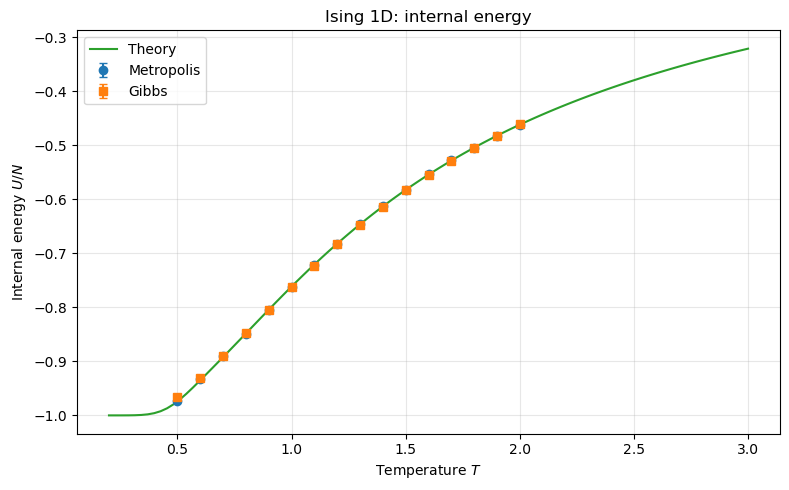

In [47]:
plot_observable(
    E_met,
    E_met_err,
    E_gib,
    E_gib_err,
    ylabel='Internal energy $U/N$',
    title='Ising 1D: internal energy',
    theory_T=T_theory,
    theory_values=E_theory
)

**Figure 1.** The figure shows the internal energy $U(N,T)$ obtained from the simulations performed with the Metropolis and Gibbs sampling algorithms, together with the corresponding theoretical prediction. The agreement between the two sampling methods and the theoretical curve is used to verify the correct implementation of the Gibbs algorithm.

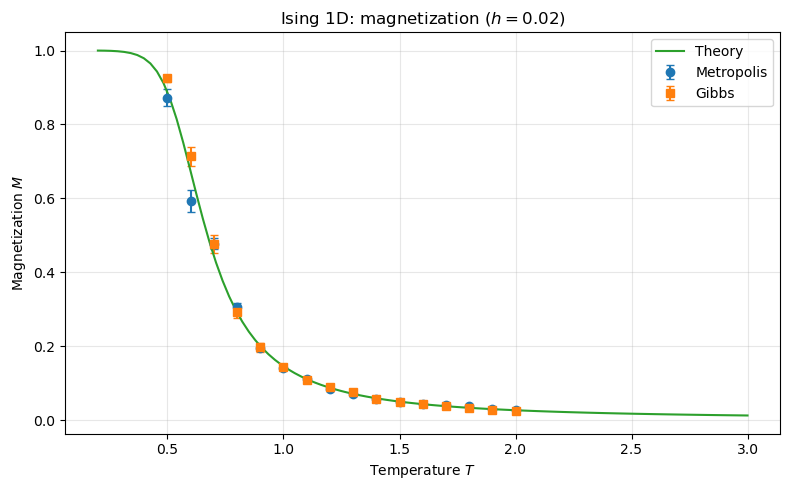

In [48]:
plot_observable(
    M_met,
    M_met_err,
    M_gib,
    M_gib_err,
    ylabel='Magnetization $M$',
    title='Ising 1D: magnetization ($h = 0.02$)',
    theory_T=T_theory,
    theory_values=M_theory
)

**Figure 2.** The figure shows the magnetization $M(N,T)$ obtained with the Metropolis and Gibbs sampling algorithms in the presence of an external magnetic field $h=0.02$, together with the corresponding theoretical prediction. The agreement between the two sampling methods and the theoretical curve provides a check of the implementation of the Gibbs sampling algorithm.

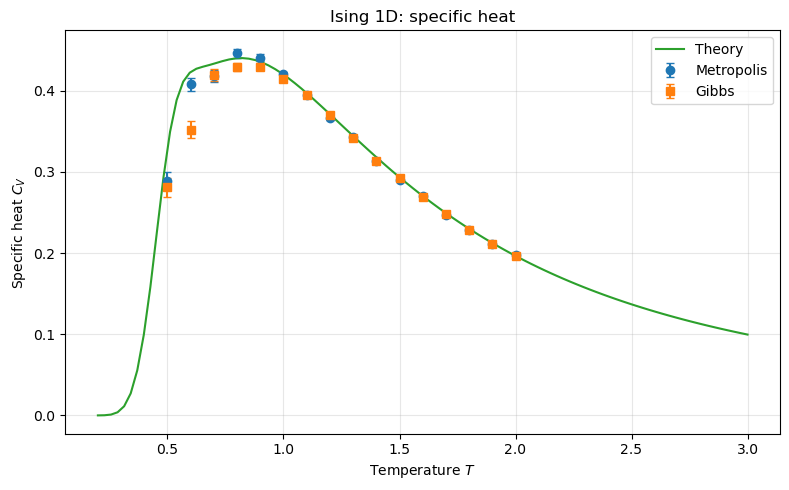

In [49]:
plot_observable(
    Cv_met,
    Cv_met_err,
    Cv_gib,
    Cv_gib_err,
    ylabel='Specific heat $C_V$',
    title='Ising 1D: specific heat',
    theory_T=T_theory,
    theory_values=heat_theory
)

**Figure 3.** The figure shows the specific heat $C(N,T)$ obtained using the Metropolis and Gibbs sampling algorithms, together with the corresponding theoretical prediction. The statistical uncertainties are estimated through the data blocking method, allowing the agreement between the two sampling methods and the theoretical result to be assessed.

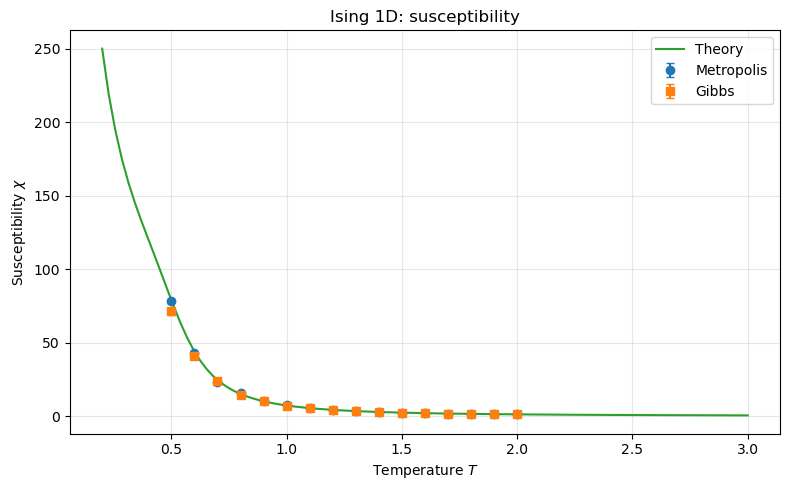

In [50]:
plot_observable(
    Chi_met,
    Chi_met_err,
    Chi_gib,
    Chi_gib_err,
    ylabel='Susceptibility $\\chi$',
    title='Ising 1D: susceptibility',
    theory_T=T_theory,
    theory_values=X_theory
)

**Figure 4.** The figure shows the magnetic susceptibility $\chi(N,T)$ calculated with the Metropolis and Gibbs sampling algorithms, together with the corresponding theoretical prediction. The results obtained with the two sampling methods are compared with the theoretical curve to verify the correct sampling of the equilibrium distribution.